In [1]:
print('hello')

hello


In [ ]:
# %%
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.distributions as dists
torch.manual_seed(0)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = True

from mnist import get_mnist_loaders
from LeNet import LeNet

from netcal.metrics import ECE, MCE

from laplace import Laplace
import redux_utils
from dataclasses import dataclass, asdict
import copy
# ------------------------
# Training / Eval
# ------------------------
def train_epoch(model, loader, optimizer, criterion, device, max_iter = None, reg=False):
    if max_iter == None:
        max_iter = len(loader)
    model.train()
    total_loss = 0
    losses = []
    counter = 0

    for x, y in loader:
        if counter == max_iter:
            return total_loss / max_iter, losses
        counter += 1
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        if reg:
            l2_lambda = 1e-5
            l2_reg = torch.tensor(0., device=device)
            for param in model.parameters():
                l2_reg += torch.norm(param, p=2)**2
            loss = criterion(logits, y) + l2_lambda * l2_reg
        else:
            loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        losses += [loss.item()]


    return total_loss / len(loader), losses


def evaluate(model, loader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            logits = model(x)
            preds = logits.argmax(dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total

def print_model_params(model):
    total = 0

    for name, param in model.named_parameters():
        if param.requires_grad:
            n = param.numel()
            total += n

            shape = str(tuple(param.shape))  # <-- fix

            print(f"{name:20s} | shape: {shape:15s} | params: {n}")

    print("-" * 60)
    print(f"Total trainable params: {total}")



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LeNet(activation="tanh").to(device)
model.load_state_dict(torch.load("adam_map.pth", map_location=device))

mnist_train_loader, mnist_test_loader = get_mnist_loaders(test_batch_size=10000)

mnist_targets = torch.cat([y for x, y in mnist_test_loader], dim=0)

@torch.no_grad()
def predict(dataloader, model, laplace=False):
    py = []

    for x, _ in dataloader:
        if laplace:
            py.append(model(x.cuda()))
        else:
            py.append(torch.softmax(model(x.cuda()), dim=-1))

    return torch.cat(py).cpu()

probs_map = predict(mnist_test_loader, model, laplace=False)
acc_map = (probs_map.argmax(-1) == mnist_targets).float().mean()
ece_map = ECE(bins=10).measure(probs_map.numpy(), mnist_targets.numpy())
mce_map = MCE(bins=10).measure(probs_map.numpy(), mnist_targets.numpy())
nll_map = -dists.Categorical(probs_map).log_prob(mnist_targets).mean()
print(f"[MAP] Acc.: {acc_map:.1%}; ECE: {ece_map:.1%}; MCE: {mce_map:.1%}; NLL: {nll_map:.3}")


[MAP] Acc.: 98.9%; ECE: 0.7%; MCE: 24.8%; NLL: 0.0454


In [3]:
la = Laplace(model, "classification",
             subset_of_weights="last_layer",
             hessian_structure="kron", prior_precision = 1.0)
la.fit(mnist_train_loader)
#la.optimize_prior_precision(method="marglik",link_approx = 'mc', n_samples = 10)
probs_laplace = predict(mnist_test_loader, la, laplace=True)
acc_laplace = (probs_laplace.argmax(-1) == mnist_targets).float().mean()

ece_laplace = ECE(bins=15).measure(probs_laplace.numpy(), mnist_targets.numpy())
mce_laplace = MCE(bins=10).measure(probs_laplace.numpy(), mnist_targets.numpy())
nll_laplace = -dists.Categorical(probs_laplace).log_prob(mnist_targets).mean()

print(f"[Laplace] Acc.: {acc_laplace:.4%}; ECE: {ece_laplace:.4%}; MCE: {mce_laplace:.4%}; NLL: {nll_laplace:.4}")

[Laplace] Acc.: 98.8500%; ECE: 0.9872%; MCE: 14.9443%; NLL: 0.04258


In [24]:
import numpy as np
from sklearn.metrics import roc_auc_score
def get_calib(pys, y_true, M=10):
    if y_true.ndim > 1:
        y_true = np.argmax(y_true, axis=1)

    preds = np.argmax(pys, axis=1)
    confs = np.max(pys, axis=1)

    bin_boundaries = np.linspace(0, 1, M + 1)
    conf_idxs = np.digitize(confs, bin_boundaries, right=True) - 1
    conf_idxs = np.clip(conf_idxs, 0, M - 1)

    accs_bin, confs_bin, nitems_bin = [], [], []

    for i in range(M):
        in_bin = (conf_idxs == i)
        n_in_bin = np.sum(in_bin)

        if n_in_bin > 0:
            bin_acc = np.mean(preds[in_bin] == y_true[in_bin])
            bin_conf = np.mean(confs[in_bin])

            accs_bin.append(bin_acc)
            confs_bin.append(bin_conf)
            nitems_bin.append(n_in_bin)

    if not accs_bin:
        return 0.0, 0.0

    accs_bin = np.array(accs_bin)
    confs_bin = np.array(confs_bin)
    nitems_bin = np.array(nitems_bin)

    gaps = np.abs(accs_bin - confs_bin)
    weights = nitems_bin / np.sum(nitems_bin)

    ECE = np.sum(gaps * weights)
    MCE = np.max(gaps)

    return ECE, MCE

def get_brier_score(probs, y_true):
    return np.mean(np.sum((probs - y_true) ** 2, axis=1))


import torch
import torch.nn.functional as F
import torch
import torch.nn.functional as F
import torch.distributions as dists
import numpy as np
from sklearn.metrics import roc_auc_score
mnist_targets_tensor = torch.cat([y for x, y in mnist_test_loader]).cpu()

def move_laplace_to_cuda(la):
    """
    Safely moves any Laplace structure (Kron, LowRank, Diag, Full) to CUDA.
    """
    # 1. Move the model
    la.model.cuda()
    la.model.output_size = 10 
    
    # 2. Move the prior precision (stored as a tensor)
    if torch.is_tensor(la.prior_precision):
        la.prior_precision = la.prior_precision.cuda()
    
    # 3. Handle the Hessian (la.H)
    if hasattr(la, 'H') and la.H is not None:
        if torch.is_tensor(la.H): # Full or Diag
            la.H = la.H.cuda()
        elif isinstance(la.H, tuple): # LowRank (eigenvecs, eigenvals)
            la.H = tuple(h.cuda() if torch.is_tensor(h) else h for h in la.H)
        elif hasattr(la.H, 'to'): # KronDecomposed or other objects
            try:
                la.H.to('cuda')
            except:
                pass
    return la

# ==========================================
# 2. Prediction Function (Unified Laplace)
# ==========================================
@torch.no_grad()
def get_laplace_probs(dataloader, la, sample=True, n_samples=100):
    # Ensure everything is synced on GPU
    la = move_laplace_to_cuda(la)
    
    py = []
    for x, _ in dataloader:
        x_cuda = x.cuda()
        
        # This context manager forces internal torch.eye (the bug) to be on CUDA
        with torch.device('cuda'):
            if sample:
                # MC Sampling (NN path)
                logits_samples = la.predictive_samples(x_cuda, n_samples=n_samples, pred_type='nn')
                probs = logits_samples.mean(dim=0)
            else:
                # Linearised (GLM path)
                probs = la(x_cuda, pred_type='glm')
        
        py.append(probs.cpu())

    return torch.cat(py)

# ==========================================
# 3. Full Evaluation Suite
# ==========================================
def evaluate_laplace_full(la, mnist_loader, fmnist_loader, mnist_targets, sample=True, n_samples=100):
    # --- A. In-Distribution (MNIST) ---
    probs_mnist = get_laplace_probs(mnist_loader, la, sample=sample, n_samples=n_samples)
    
    # NLL Calculation

    
    nll = -dists.Categorical(probs=probs_mnist).log_prob(mnist_targets).mean().item()
    
    # Accuracy
    acc = (probs_mnist.argmax(-1) == mnist_targets.cpu()).float().mean().item()
    
    # Calibration & Brier (Using your provided numpy functions)
    probs_np = probs_mnist.numpy()
    y_true_np = mnist_targets.cpu().numpy()
    y_onehot = np.eye(10)[y_true_np]
    
    ece, mce = get_calib(probs_np, y_onehot)
    brier = get_brier_score(probs_np, y_onehot)
    mnist_conf = np.mean(np.max(probs_np, axis=1))

    # --- B. Out-of-Distribution (FashionMNIST) ---
    probs_fmnist = get_laplace_probs(fmnist_loader, la, sample=sample, n_samples=n_samples)
    fmnist_conf = np.mean(np.max(probs_fmnist.numpy(), axis=1))

    # --- C. OOD AUROC ---
    m_scores = 1 - np.max(probs_np, axis=1)
    f_scores = 1 - np.max(probs_fmnist.numpy(), axis=1)
    
    all_scores = np.concatenate([m_scores, f_scores])
    all_labels = np.concatenate([np.zeros(len(m_scores)), np.ones(len(f_scores))])
    auroc = roc_auc_score(all_labels, all_scores)

    return {
        "acc": acc, "nll": nll, "ece": ece, "mce": mce,
        "brier": brier, "conf": mnist_conf, "f_conf": fmnist_conf, 
        "auroc": auroc
    }

In [28]:
from mnist import get_mnist_loaders, get_fmnist_loaders
_, mnist_loader = get_mnist_loaders(test_batch_size=10000)
_, fmnist_loader = get_fmnist_loaders(test_batch_size=10000)

# la = Laplace(model, "classification",
#              subset_of_weights="last_layer",
#              hessian_structure="kron", prior_precision = 1.0)
# la.fit(mnist_train_loader)

# results = evaluate_laplace_full(la, mnist_loader, fmnist_loader, mnist_targets_tensor,sample=False)
# print(results)
# la = Laplace(model, "classification",
#              subset_of_weights="last_layer",
#              hessian_structure="kron", prior_precision = 1.0)
# la.fit(mnist_train_loader)

# results = evaluate_laplace_full(la, mnist_loader, fmnist_loader, mnist_targets_tensor,sample=True, n_samples =10)
# print(results)

la = Laplace(model, "classification",
             subset_of_weights="all",
             hessian_structure="lowrank",
              backend_kwargs={'low_rank': 10},
             prior_precision = 1.0)
la.fit(mnist_train_loader)

results = evaluate_laplace_full(la, mnist_loader, fmnist_loader, mnist_targets_tensor,sample=True, n_samples =10)
print(results)

{'acc': 0.10660000145435333, 'nll': 3.1585779190063477, 'ece': 0.15213191104829313, 'mce': 0.7067024111747742, 'brier': 0.9577889136959189, 'conf': 0.2587319, 'f_conf': 0.25170684, 'auroc': 0.5352346400000001}


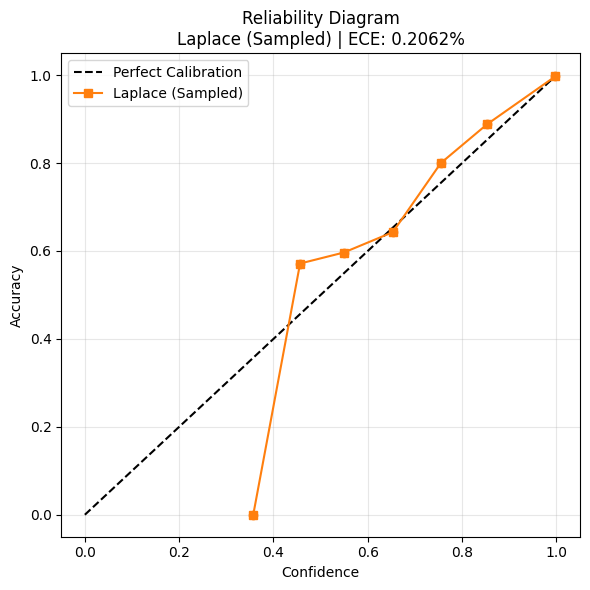

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def plot_laplace_calibration_only(la, mnist_loader, M=10, n_samples=100, sample=True, device='cuda'):
    """
    Dedicated Reliability Diagram for Laplace (Sampled or Linearised).
    """
    # 1. Get Marginalised Probs [N, 10] and True Labels [N]
    # Uses the unified get_laplace_probs we built (handles GPU/Kron/LowRank)
    probs_lp_tensor = get_laplace_probs(mnist_loader, la, sample=sample, n_samples=n_samples)
    probs_lp = probs_lp_tensor.numpy()
    
    # Extract labels from loader
    y_true = torch.cat([y for x, y in mnist_loader]).cpu().numpy()
    
    # 2. Calculate Confidence and Predictions
    confs_lp = np.max(probs_lp, axis=1)
    preds_lp = np.argmax(probs_lp, axis=1)

    # 3. Binning Logic
    plt.figure(figsize=(6,6))
    plt.plot([0,1],[0,1], '--', color='black', label='Perfect Calibration')
    
    bins = np.linspace(0, 1, M + 1)
    # Digitize: assign each confidence to a bin index
    idx_lp = np.clip(np.digitize(confs_lp, bins, right=True) - 1, 0, M-1)
    
    accs_bin = []
    confs_bin = []
    counts_bin = []

    for i in range(M):
        mask = (idx_lp == i)
        if np.any(mask):
            acc_bin = np.mean(preds_lp[mask] == y_true[mask])
            conf_bin = np.mean(confs_lp[mask])
            count = np.sum(mask)
        else:
            acc_bin = np.nan
            conf_bin = (bins[i] + bins[i+1]) / 2
            count = 0
            
        accs_bin.append(acc_bin)
        confs_bin.append(conf_bin)
        counts_bin.append(count)

    return confs_bin,accs_bin 

# ---------------------------------------------------------
# Usage:
# ---------------------------------------------------------
la = Laplace(model, "classification",
             subset_of_weights="last_layer",
             hessian_structure="kron", prior_precision = 1.0)
la.fit(mnist_train_loader)

plot_laplace_calibration_only(la, mnist_test_loader, sample=True, n_samples=100)
